# GoalLab Stage 04: Approximate evidence values with DQN

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 03](03_q_learning.ipynb) · [Stage 05](05_policy_gradient.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/apply-theory/04_dqn.ipynb)

**Build:** replace the evidence Q-table with a neural value function while keeping the task and evaluator fixed.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 04](../../../notebooks/04_dqn.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Trace replay tensors and terminal masks; implement a target network; compare approximation against a Q-table.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: the replay batch is a contract

Each row contains one chosen action, not a target for every action. `gather` selects the corresponding prediction. Terminal masking removes the target-network prediction from the last transition. Deliberately use a large terminal next-state value below; a missing mask would then be obvious.

The target is detached. If gradients flow through both online and target predictions, this is no longer the intended semi-gradient DQN update.

In [2]:
from torch import nn
predicted=torch.tensor([[.2,.7],[.4,.9]],requires_grad=True)
actions=torch.tensor([1,0]); reward=torch.tensor([-.02,.98]); done=torch.tensor([0.,1.])
next_values=torch.tensor([.8,100.])
target=(reward+(1-done)*next_values).detach()
chosen=predicted.gather(1,actions[:,None]).squeeze(1)
loss=nn.functional.smooth_l1_loss(chosen,target); loss.backward()
print('Targets:',target.tolist(),'Selected predictions:',chosen.detach().tolist())
print('Gradient by action:',predicted.grad.tolist())
assert np.isclose(target[1],.98) and predicted.grad[0,0]==0 and predicted.grad[1,1]==0

Targets: [0.7800000309944153, 0.9800000190734863] Selected predictions: [0.699999988079071, 0.4000000059604645]
Gradient by action: [[0.0, -0.04000002145767212], [-0.2900000214576721, 0.0]]


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
def network(outputs):
    return nn.Sequential(nn.Linear(7, 32), nn.Tanh(), nn.Linear(32, outputs))


def train_dqn(seed=7, episodes=600):
    torch.manual_seed(seed)
    env, rng = EvidenceMDP(), np.random.default_rng(seed)
    features = torch.tensor(env.features())
    online, replay = network(2), deque(maxlen=3000)
    target = deepcopy(online).requires_grad_(False)
    optimizer = torch.optim.Adam(online.parameters(), lr=.003)
    history, losses, steps = [], [], 0
    for ep in range(episodes):
        s = env.start_index
        epsilon = max(.08, .8 * (1 - ep / episodes))
        for _ in range(4):
            with torch.no_grad():
                a = int(rng.integers(2)) if rng.random() < epsilon else int(online(features[s]).argmax())
            ns, r, done = env.step(s, a, rng)
            replay.append((s, a, r, ns, done))
            s, steps = ns, steps + 1
            if len(replay) >= 64:
                batch = np.array([replay[i] for i in rng.choice(len(replay), 64, replace=False)])
                bs, ba, br, bn, bd = [torch.tensor(batch[:, i], dtype=torch.long if i in (0, 1, 3) else torch.float32)
                                      for i in range(5)]
                with torch.no_grad():
                    labels = br + (1 - bd) * target(features[bn]).max(1).values
                loss = nn.functional.smooth_l1_loss(online(features[bs]).gather(1, ba[:, None]).squeeze(1), labels)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), 5); optimizer.step()
                losses.append(float(loss.detach()))
            if steps % 100 == 0:
                target.load_state_dict(online.state_dict())
        if (ep + 1) % 24 == 0:
            with torch.no_grad():
                policy = greedy(online(features).numpy())
            history.append((steps, env.values(policy)[0][env.start_index]))
    with torch.no_grad():
        policy = greedy(online(features).numpy())
    return {'env': env, 'policy': policy, 'model': online, 'history': np.array(history), 'losses': losses}

## 1. DQN on evidence features

Seven features encode phase, inspected-source flags, inferred authority, and citation. A two-layer network predicts two action values. Replay samples older transitions; a frozen target network is refreshed every 100 actions. The update uses Huber loss, gradient clipping, and `reward + (1-done)*max Q_target(next)`.

This stage demonstrates approximation mechanics. The compact task does not need a neural network, so the tabular method remains an essential baseline.

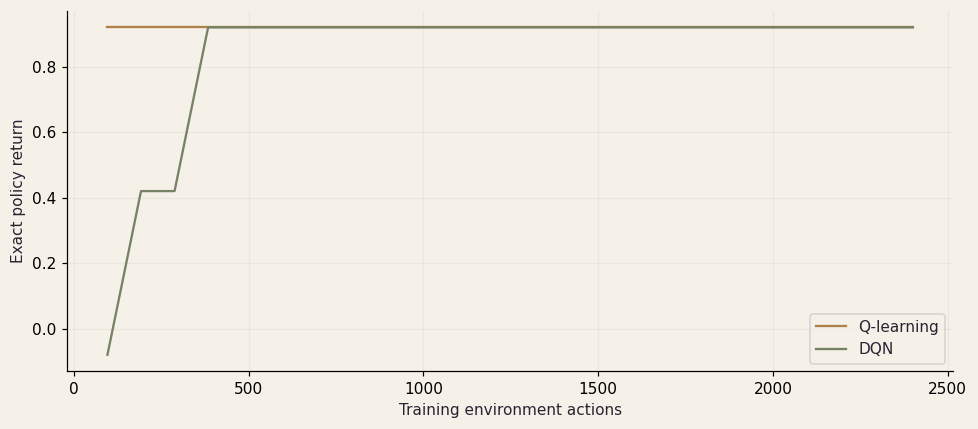

| Controller | Exact return | Held-out briefing success | Calls/case |
|---|---|---|---|
| Q-learning | 0.92 | 100.0% | 4.0 |
| DQN | 0.92 | 100.0% | 4.0 |

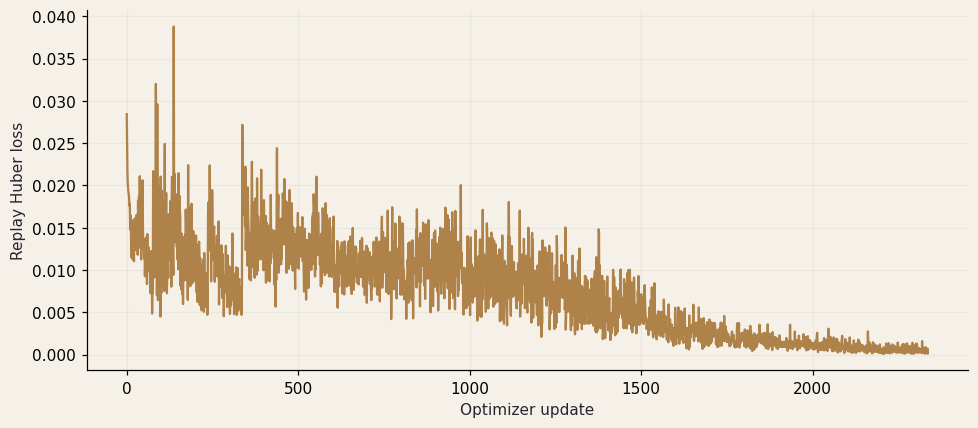

In [4]:
runs = {'Q-learning':learning.train_tabular('Q-learning',7,600),'DQN':train_dqn(7,600)}
learning_plot(runs); report_policies(runs)
plt.plot(runs['DQN']['losses']); plt.xlabel('Optimizer update'); plt.ylabel('Replay Huber loss'); plt.tight_layout(); plt.show()

## 2. Execute the neural controller

Held-out payloads are new, but the seven abstract features have the same meaning. Strong results here show routing under this schema, not comprehension of arbitrary source text.

In [5]:
session = runs['DQN']['env'].deploy(runs['DQN']['policy'], goal.make_workspace(99,'test'))
print(session.artifact,goal.verify(session.workspace,session.artifact))

Briefing(value=14, citation='test-99-source-0', period='2026-02', abstained=False) {'success': True, 'supported': True, 'value_correct': True}


## Interpret the evidence

DQN can match the tabular optimum on this compact feature space. That does not show an advantage over a Q-table. Inspect stability and resource cost, and keep the simpler method as a baseline.

## Change a constraint: predict first

Compare another training seed. Does a falling replay loss alone establish better end-to-end briefing success?

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
other = train_dqn(19,600)
report_policies({'DQN seed 7':runs['DQN'],'DQN seed 19':other})
print('Use final evaluation, not replay loss alone, to assess the submitted artifact.')

| Controller | Exact return | Held-out briefing success | Calls/case |
|---|---|---|---|
| DQN seed 7 | 0.92 | 100.0% | 4.0 |
| DQN seed 19 | 0.92 | 100.0% | 4.0 |

Use final evaluation, not replay loss alone, to assess the submitted artifact.


## What this stage contributes

A neural action-value controller that shares the same workspace adapter. Theory: [DQN](../../../chapters/22-deep-q-networks/README.md).

[Stage 03](03_q_learning.ipynb) · [Stage 05](05_policy_gradient.ipynb)